### Libraries

In [1]:
import logging
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from investment_lab.data.option_db import OptionLoader, extract_spot_from_options
from investment_lab.data.rates_db import USRatesLoader
from investment_lab.rates import compute_forward

from investment_lab.surface.reference_iv import (
    SVIReferenceIVExtractor,
    SSVIReferenceIVExtractor,
)

from investment_lab.stochastic.heston_ssm import HestonStateSpaceModel

from investment_lab.signals.implied_realized_spread import build_implied_realized_spread
from investment_lab.signals.allocation import build_zscore_allocation_signal, build_percentile_allocation_signal

from investment_lab.option_trade import VarianceSwap
from investment_lab.backtest import BacktesterBidAskFromData
from investment_lab.strategies.dynamic_allocation import DynamicAllocationOverlay

from investment_lab.metrics.performance import evaluate_backtest 
from investment_lab.signals.naive_spread import build_naive_implied_realized_spread

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
)

### Inputs

In [3]:
TICKER = "SPY"

START_DATE = datetime(2020, 1, 2)
END_DATE = datetime(2022, 12, 30)

TARGET_DTE = 30
TARGET_MONEYNESS = 1.0

ROLLING_WINDOW = 126
FORECAST_HORIZON_DAYS = 30

USE_SURFACE_MODEL = "SSVI"   

ZSCORE_ROLLING_WINDOW = 60
HIGH_THRESHOLD = 0.6
LOW_THRESHOLD = 0.4
MIN_ALLOCATION = -0.3
MAX_ALLOCATION = 1.0
ZSCORE_SCALING = 0.25
ZSCORE_CENTER = 0.5

### Load data

In [ ]:
df_options = OptionLoader.load_data(
    start_date=START_DATE,
    end_date=END_DATE,
    process_kwargs={"ticker": TICKER},
)

df_options = df_options.sort_values(["date", "expiration", "strike"]).reset_index(drop=True)
df_options.head()

2026-04-07 17:21:22,732 - INFO - Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None


In [ ]:
df_rates = USRatesLoader.load_data(
    start_date=max(START_DATE, datetime(2020, 1, 2)),
    end_date=END_DATE,
)

df_options = compute_forward(df_options=df_options, df_rates=df_rates)
df_options.head()

2026-04-07 12:40:33,130 - INFO - Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/par-yield-curve-rates-2020-2023.csv with None
2026-04-07 12:40:34,063 - INFO - Processing with None
2026-04-07 12:40:34,064 - INFO - Potentially add extra field with None
C:\Users\33761\OneDrive - CentraleSupelec\Documents\Cours 4A\Stratégie de la volatilité\Code\Dauphine-Lecture-Volatility\investment_lab\rates.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_values)


,spot,strike,expiration,delta,gamma,vega,theta,rho,implied_volatility,bid,...,volume,call_put,option_id,mid,ticker,date,day_to_expiration,moneyness,risk_free_rate,forward
0,324.87,260.0,2020-01-03,1.00000,0.00000,0.00000,-0.00041,0.01423,0.00000,64.56,...,1.0,C,SPY 20200103C260,64.660,SPY,2020-01-02,1,0.800320,0.015300,324.883609
1,324.87,293.0,2020-09-30,-0.24350,0.00628,0.87615,-0.03130,-0.64979,0.17822,7.77,...,1.0,P,SPY 20200930P293,7.825,SPY,2020-01-02,272,0.901899,0.015651,328.678601
2,324.87,293.0,2020-09-30,0.73435,0.00583,0.90409,-0.02956,1.15850,0.21085,40.01,...,5.0,C,SPY 20200930C293,40.110,SPY,2020-01-02,272,0.901899,0.015651,328.678601
3,324.87,292.0,2020-09-30,-0.23629,0.00617,0.86177,-0.03042,-0.62930,0.17746,7.21,...,476.0,P,SPY 20200930P292,7.480,SPY,2020-01-02,272,0.898821,0.015651,328.678601
4,324.87,292.0,2020-09-30,0.74014,0.00577,0.89429,-0.02866,1.15671,0.21294,40.81,...,0.0,C,SPY 20200930C292,40.925,SPY,2020-01-02,272,0.898821,0.015651,328.678601


In [ ]:
df_spot = extract_spot_from_options(df_options).copy()
df_spot["ticker"] = TICKER
df_spot = df_spot.sort_values("date").reset_index(drop=True)
df_spot["log_spot"] = np.log(df_spot["spot"])
df_spot["log_return"] = df_spot["log_spot"].diff()
df_spot.head()

,date,spot,ticker,log_spot,log_return
0,2020-01-02,324.87,SPY,5.783425,NaN
1,2020-01-03,322.43,SPY,5.775886,-0.007539
2,2020-01-06,323.68,SPY,5.779755,0.003869
3,2020-01-07,322.74,SPY,5.776847,-0.002908
4,2020-01-08,324.39,SPY,5.781946,0.005099


### Implied vol

In [ ]:
if USE_SURFACE_MODEL.upper() == "SVI":
    iv_extractor = SVIReferenceIVExtractor(
        target_day_to_expiration=TARGET_DTE,
        target_moneyness=TARGET_MONEYNESS,
        minimum_points_per_expiry=5,
    )
elif USE_SURFACE_MODEL.upper() == "SSVI":
    iv_extractor = SSVIReferenceIVExtractor(
        target_day_to_expiration=TARGET_DTE,
        target_moneyness=TARGET_MONEYNESS,
        minimum_points_per_expiry=5,
    )
else:
    raise ValueError("USE_SURFACE_MODEL must be 'SVI' or 'SSVI'.")

df_iv_reference = iv_extractor.extract(df_options)
df_iv_reference.head()

2026-04-07 12:43:14,997 - INFO - Extracting reference IV on 7178158 option rows.


2026-04-07 12:43:23,714 - INFO - After filtering: 6630716 rows remaining.
2026-04-07 12:43:25,360 - INFO - Fitting SSVI model on 156 records
2026-04-07 12:43:25,386 - INFO - Successfully fitted SSVI. Parameters: [ 0.2 -0.3  0.5  0.2]
2026-04-07 12:43:25,393 - INFO - Fitting SSVI model on 77 records
2026-04-07 12:43:25,396 - INFO - Successfully fitted SSVI. Parameters: [ 0.2 -0.3  0.5  0.2]
2026-04-07 12:43:25,398 - INFO - Fitting SSVI model on 81 records
2026-04-07 12:43:25,401 - INFO - Successfully fitted SSVI. Parameters: [ 0.2 -0.3  0.5  0.2]
2026-04-07 12:43:25,405 - INFO - Fitting SSVI model on 127 records
2026-04-07 12:43:25,407 - INFO - Successfully fitted SSVI. Parameters: [ 0.2 -0.3  0.5  0.2]
2026-04-07 12:43:25,410 - INFO - Fitting SSVI model on 100 records
2026-04-07 12:43:25,414 - INFO - Successfully fitted SSVI. Parameters: [ 0.19998797 -0.3000001   0.50000008  0.20000028]
2026-04-07 12:43:25,416 - INFO - Fitting SSVI model on 105 records
2026-04-07 12:43:25,420 - INFO - 

,date,ticker,iv_reference,target_day_to_expiration,target_moneyness,n_fitted_expiries
0,2020-01-02,SPY,0.184890,30,1.0,37
1,2020-01-03,SPY,0.175630,30,1.0,37
2,2020-01-06,SPY,0.135746,30,1.0,36
3,2020-01-07,SPY,0.155383,30,1.0,37
4,2020-01-08,SPY,0.162833,30,1.0,36


### Heston state space model

In [ ]:
heston_ssm = HestonStateSpaceModel(
    rolling_window=ROLLING_WINDOW,
    forecast_horizon_days=FORECAST_HORIZON_DAYS,
    measurement_error=1e-6,
    variance_proxy_error=0.01,
    rv_proxy_window=15,
)

df_heston = heston_ssm.rolling_fit_predict(
    df_spot[["date", "spot"]],
    recalibration_frequency=5,   
)
df_heston["ticker"] = TICKER

2026-04-07 12:54:52,637 - INFO - Diffusion params (moments): xi=0.753, rho=-0.032, mu=0.152 | Initial kappa=5.00, theta=0.0355 (vol=18.8%)
2026-04-07 12:57:49,294 - INFO - Hybrid calibrated: kappa=4.730, theta=0.0599 (vol=24.5%) | fixed xi=0.753, rho=-0.032 | NLL=-716.04
2026-04-07 12:57:49,302 - INFO - Diffusion params (moments): xi=0.752, rho=-0.032, mu=0.167 | Initial kappa=5.00, theta=0.0355 (vol=18.8%)
2026-04-07 12:59:50,695 - INFO - Hybrid calibrated: kappa=4.895, theta=0.0577 (vol=24.0%) | fixed xi=0.752, rho=-0.032 | NLL=-717.80
2026-04-07 12:59:50,700 - INFO - Diffusion params (moments): xi=0.752, rho=-0.031, mu=0.167 | Initial kappa=5.00, theta=0.0355 (vol=18.8%)
2026-04-07 13:02:02,849 - INFO - Hybrid calibrated: kappa=4.967, theta=0.0569 (vol=23.8%) | fixed xi=0.752, rho=-0.031 | NLL=-720.52
2026-04-07 13:02:02,854 - INFO - Diffusion params (moments): xi=0.753, rho=-0.033, mu=0.148 | Initial kappa=5.00, theta=0.0355 (vol=18.8%)
2026-04-07 13:04:24,102 - INFO - Hybrid calib

2026-04-07 13:10:14,502 - INFO - Hybrid calibrated: kappa=4.898, theta=0.0572 (vol=23.9%) | fixed xi=0.748, rho=-0.029 | NLL=-734.08
2026-04-07 13:10:14,508 - INFO - Diffusion params (moments): xi=0.752, rho=-0.035, mu=0.165 | Initial kappa=5.00, theta=0.0367 (vol=19.2%)
2026-04-07 13:12:31,844 - INFO - Hybrid calibrated: kappa=4.702, theta=0.0602 (vol=24.5%) | fixed xi=0.752, rho=-0.035 | NLL=-736.13
2026-04-07 13:12:31,849 - INFO - Diffusion params (moments): xi=0.765, rho=-0.010, mu=0.188 | Initial kappa=5.00, theta=0.0347 (vol=18.6%)
2026-04-07 13:14:06,356 - INFO - Hybrid calibrated: kappa=4.950, theta=0.0592 (vol=24.3%) | fixed xi=0.765, rho=-0.010 | NLL=-728.05
2026-04-07 13:14:06,361 - INFO - Diffusion params (moments): xi=0.772, rho=-0.010, mu=0.216 | Initial kappa=4.68, theta=0.0345 (vol=18.6%)
2026-04-07 13:15:40,948 - INFO - Hybrid calibrated: kappa=4.362, theta=0.0684 (vol=26.2%) | fixed xi=0.772, rho=-0.010 | NLL=-729.89
2026-04-07 13:15:40,953 - INFO - Diffusion params (

In [ ]:
print("=== Paramètres calibrés ===")
print(df_heston[["kappa", "theta", "xi", "rho"]].describe())
print()
print("=== Forecast vs proxies ===")
print(f"Forecast vol  : {df_heston['forecast_volatility'].describe()}")
print(f"Filtered var  : {df_heston['filtered_variance'].describe()}")
if "rv_proxy" in df_heston.columns:
    print(f"RV proxy      : {df_heston['rv_proxy'].describe()}")
print()
print(f"sqrt(theta) moyen = {np.sqrt(df_heston['theta'].mean()):.4f}")
print(f"sqrt(filtered_var) moyen = {np.sqrt(df_heston['filtered_variance'].mean()):.4f}")

=== Paramètres calibrés ===
            kappa       theta          xi         rho
count  507.000000  507.000000  507.000000  507.000000
mean     4.935463    0.010409    0.201816   -0.081145
std      0.257154    0.015916    0.183946    0.075573
min      2.932118    0.005000    0.100000   -0.257520
25%      5.000000    0.005000    0.116099   -0.139286
50%      5.000000    0.005000    0.140480   -0.057170
75%      5.000000    0.005000    0.169224   -0.010000
max      5.000000    0.068385    0.772386   -0.010000

=== Forecast vs proxies ===
Forecast vol  : count    507.000000
mean       0.136685
std        0.038242
min        0.081173
25%        0.100236
50%        0.138392
75%        0.172722
max        0.205061
Name: forecast_volatility, dtype: float64
Filtered var  : count    507.000000
mean       0.023329
std        0.012582
min        0.007109
25%        0.011487
50%        0.023082
75%        0.032843
max        0.051968
Name: filtered_variance, dtype: float64
RV proxy      : count  

### Implied Realized spread

In [ ]:
df_spread = build_implied_realized_spread(
    df_iv_reference=df_iv_reference,
    df_heston_forecast=df_heston,
)

df_spread = df_spread.sort_values(["ticker", "date"]).reset_index(drop=True)
df_spread.head()

,date,ticker,iv_reference,forecast_volatility,filtered_variance,spread
0,2021-01-05,SPY,0.136088,0.178476,0.023222,-0.042387
1,2021-01-06,SPY,0.109811,0.178099,0.023046,-0.068288
2,2021-01-07,SPY,0.101118,0.177619,0.022823,-0.076502
3,2021-01-08,SPY,0.072997,0.177454,0.022747,-0.104457
4,2021-01-11,SPY,0.210085,0.178236,0.023110,0.031849


In [ ]:
df_spread_naive = build_naive_implied_realized_spread(
    df_iv_reference=df_iv_reference,
    df_spot=df_spot,
    rolling_window=FORECAST_HORIZON_DAYS, 
)
FIRST_TRADE_DATE = pd.to_datetime(df_spread["date"].min()).to_pydatetime()
df_spread_naive = df_spread_naive.sort_values(["ticker", "date"]).loc[df_spread_naive["date"] >= FIRST_TRADE_DATE,:].reset_index(drop=True)
df_spread_naive.head()

,date,ticker,iv_reference,rolling_realized_vol,spread
0,2021-01-05,SPY,0.136088,0.113968,0.022120
1,2021-01-06,SPY,0.109811,0.107383,0.002428
2,2021-01-07,SPY,0.101118,0.113823,-0.012706
3,2021-01-08,SPY,0.072997,0.111210,-0.038213
4,2021-01-11,SPY,0.210085,0.113497,0.096589


### Build allocations

In [ ]:
df_allocation = build_zscore_allocation_signal(
    df_spread=df_spread,
    spread_col="spread",
    rolling_window=ZSCORE_ROLLING_WINDOW,
    min_allocation=MIN_ALLOCATION,
    max_allocation=MAX_ALLOCATION,
    zscore_scaling=ZSCORE_SCALING,
    center_at=ZSCORE_CENTER,
)

df_allocation = df_allocation.dropna(subset=["allocation"]).reset_index(drop=True)
df_allocation.head()

,date,ticker,spread,spread_zscore,allocation
0,2022-01-03,SPY,0.088553,0.912733,0.912733
1,2022-01-04,SPY,0.123934,1.507315,1.000000
2,2022-01-05,SPY,0.068883,0.557057,0.557057
3,2022-01-06,SPY,0.061621,0.425426,0.425426
4,2022-01-07,SPY,0.079670,0.734533,0.734533


In [ ]:
df_allocation_naive = build_zscore_allocation_signal(
    df_spread=df_spread_naive,
    spread_col="spread",
    rolling_window=ZSCORE_ROLLING_WINDOW,
    min_allocation=MIN_ALLOCATION,
    max_allocation=MAX_ALLOCATION,
    zscore_scaling=ZSCORE_SCALING,
    center_at=ZSCORE_CENTER,
)
df_allocation_naive = df_allocation_naive.dropna(subset=["allocation"]).reset_index(drop=True)
df_allocation_naive.head()

,date,ticker,spread,spread_zscore,allocation
0,2022-01-03,SPY,0.022725,-0.068055,-0.068055
1,2022-01-04,SPY,0.058203,0.628181,0.628181
2,2022-01-05,SPY,-0.004422,-0.604983,-0.500000
3,2022-01-06,SPY,-0.011540,-0.745326,-0.500000
4,2022-01-07,SPY,0.006307,-0.398413,-0.398413


In [ ]:
df_allocation_percentile = build_percentile_allocation_signal(
    df_spread=df_spread,
    spread_col="spread",
    rolling_window=ZSCORE_ROLLING_WINDOW,
    high_threshold=HIGH_THRESHOLD,
    low_threshold=LOW_THRESHOLD,
    min_allocation=MIN_ALLOCATION,
    max_allocation=MAX_ALLOCATION,
)
df_allocation_percentile = df_allocation_percentile.dropna(subset=["allocation"]).reset_index(drop=True)
df_allocation_percentile.head()

,date,ticker,spread,spread_percentile,allocation
0,2021-01-05,SPY,-0.042387,NaN,0.0
1,2021-01-06,SPY,-0.068288,NaN,0.0
2,2021-01-07,SPY,-0.076502,NaN,0.0
3,2021-01-08,SPY,-0.104457,NaN,0.0
4,2021-01-11,SPY,0.031849,NaN,0.0


In [ ]:
df_allocation_percentile_naive = build_percentile_allocation_signal(
    df_spread=df_spread_naive,
    spread_col="spread",
    rolling_window=ZSCORE_ROLLING_WINDOW,
    high_threshold=HIGH_THRESHOLD,
    low_threshold=LOW_THRESHOLD,
    min_allocation=MIN_ALLOCATION,
    max_allocation=MAX_ALLOCATION,
)
df_allocation_percentile_naive = df_allocation_percentile_naive.dropna(subset=["allocation"]).reset_index(drop=True)
df_allocation_percentile_naive.head()

,date,ticker,spread,spread_percentile,allocation
0,2021-01-05,SPY,0.022120,NaN,0.0
1,2021-01-06,SPY,0.002428,NaN,0.0
2,2021-01-07,SPY,-0.012706,NaN,0.0
3,2021-01-08,SPY,-0.038213,NaN,0.0
4,2021-01-11,SPY,0.096589,NaN,0.0


### Plot spreads

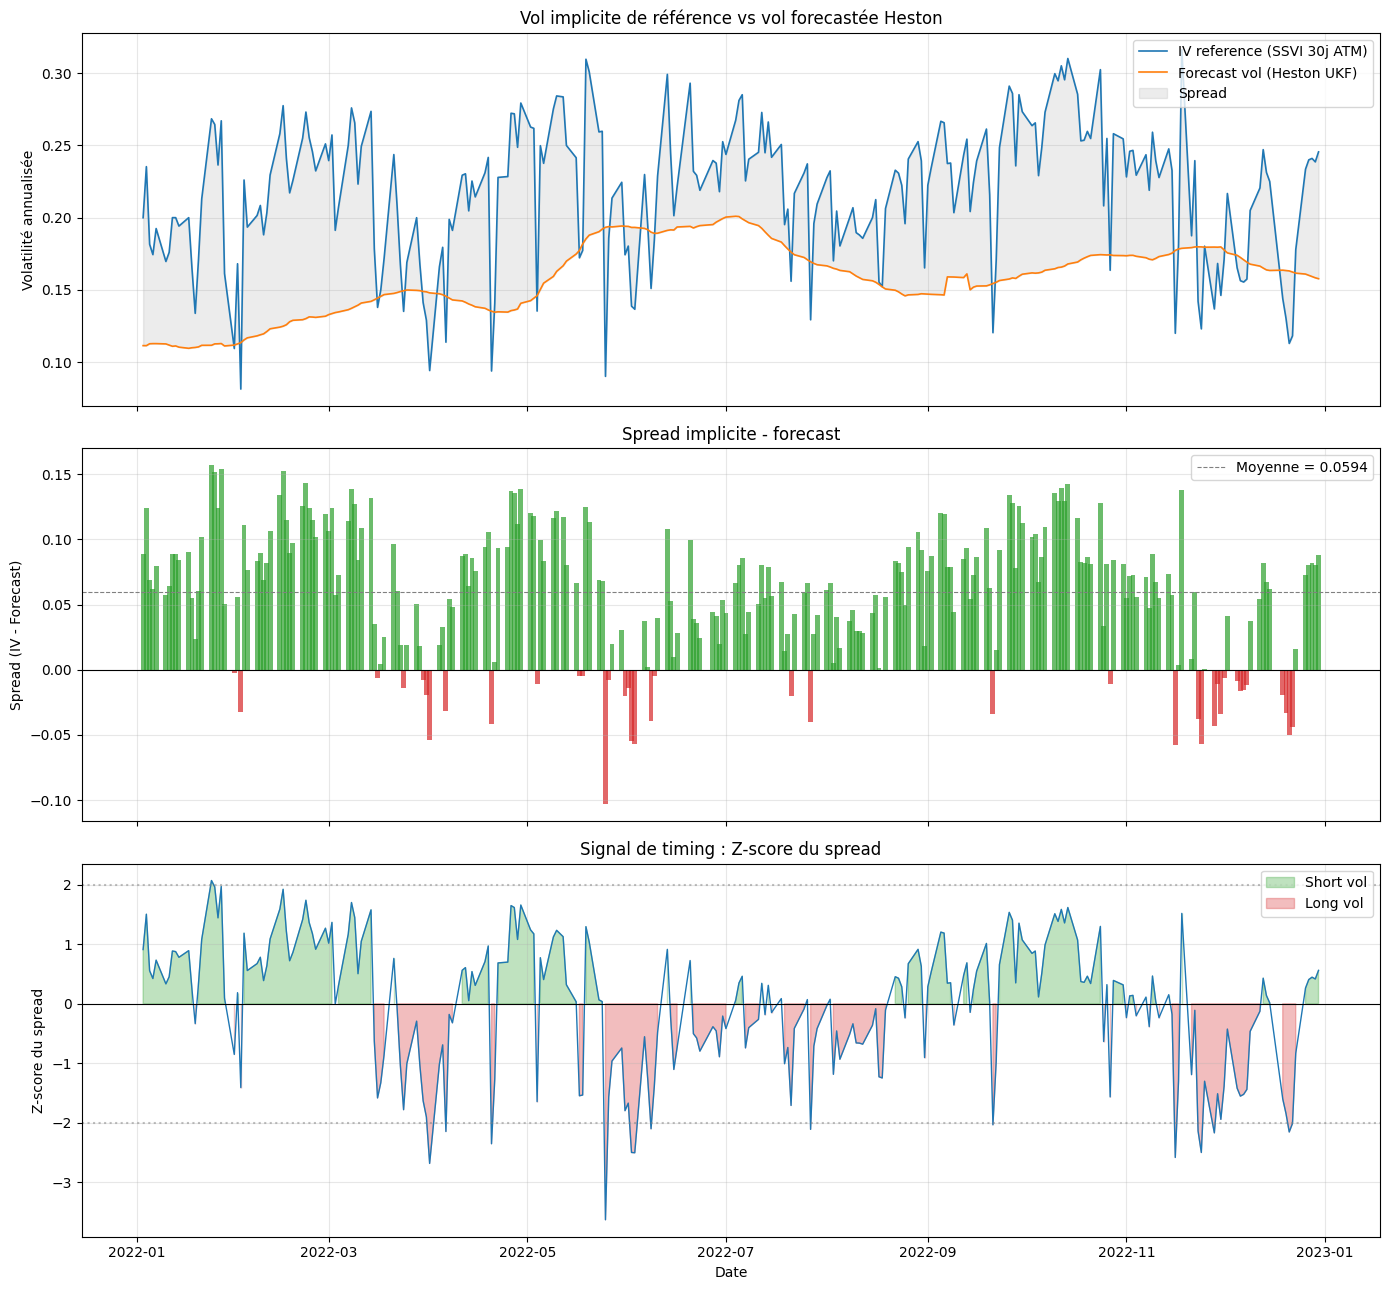

In [ ]:
df_signal_plot = (
    df_spread.merge(
        df_allocation[["date", "ticker", "allocation", "spread_zscore"]],
        on=["date", "ticker"],
        how="inner",
    )
    .sort_values("date")
)

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

# IV vs Heston vol forecast
ax1 = axes[0]
ax1.plot(df_signal_plot["date"], df_signal_plot["iv_reference"], label="IV reference (SSVI 30j ATM)", linewidth=1.2)
ax1.plot(df_signal_plot["date"], df_signal_plot["forecast_volatility"], label="Forecast vol (Heston UKF)", linewidth=1.2)
ax1.fill_between(
    df_signal_plot["date"],
    df_signal_plot["iv_reference"],
    df_signal_plot["forecast_volatility"],
    alpha=0.15,
    color="gray",
    label="Spread",
)
ax1.set_ylabel("Volatilité annualisée")
ax1.legend(loc="upper right")
ax1.set_title("Vol implicite de référence vs vol forecastée Heston")
ax1.grid(alpha=0.3)

# Spread
ax2 = axes[1]
spread = df_signal_plot["spread"]
colors = ["tab:green" if s >= 0 else "tab:red" for s in spread]
ax2.bar(df_signal_plot["date"], spread, color=colors, width=1.5, alpha=0.7)
ax2.axhline(0.0, color="black", linewidth=0.8)
ax2.axhline(spread.mean(), color="gray", linestyle="--", linewidth=0.8, label=f"Moyenne = {spread.mean():.4f}")
ax2.set_ylabel("Spread (IV - Forecast)")
ax2.legend(loc="upper right")
ax2.set_title("Spread implicite - forecast")
ax2.grid(alpha=0.3)

# Z-score
ax3 = axes[2]
zscore = df_signal_plot["spread_zscore"]
ax3.plot(df_signal_plot["date"], zscore, color="tab:blue", linewidth=1.0)
ax3.fill_between(df_signal_plot["date"], zscore, 0, where=(zscore > 0), alpha=0.3, color="tab:green", label="Short vol")
ax3.fill_between(df_signal_plot["date"], zscore, 0, where=(zscore < 0), alpha=0.3, color="tab:red", label="Long vol")
ax3.axhline(0, color="black", linewidth=0.8)
ax3.axhline(2, color="gray", linestyle=":", alpha=0.5)
ax3.axhline(-2, color="gray", linestyle=":", alpha=0.5)
ax3.set_ylabel("Z-score du spread")
ax3.set_xlabel("Date")
ax3.legend(loc="upper right")
ax3.set_title("Signal de timing : Z-score du spread")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Generate strategies

In [ ]:
VARIANCE_SWAP_LEG = [
    {
        "day_to_expiry_target": TARGET_DTE,
        "strike_spacing": 5,
        "weight": -1,
        "rebal_week_day": [0, 1, 2, 3, 4],  
    }
]

In [ ]:
df_allocation["date"] = pd.to_datetime(df_allocation["date"])

In [ ]:
# Generate var swap trades
df_trades_varswap = VarianceSwap.generate_trades(
    start_date=FIRST_TRADE_DATE,
    end_date=END_DATE,
    tickers=TICKER,
    legs=VARIANCE_SWAP_LEG,
)

# Var swap static
bt_static = BacktesterBidAskFromData(df_trades_varswap).compute_backtest()

# Var swap dynamic heston
df_trades_heston = DynamicAllocationOverlay.apply_to_trades(
    df_trades=df_trades_varswap,
    df_allocation=df_allocation,
    lag_business_days=1,
    allocation_col="allocation",
    fill_value=0.0,
)
bt_heston = BacktesterBidAskFromData(df_trades_heston).compute_backtest()

# Var swap dynamic naive
df_trades_naive = DynamicAllocationOverlay.apply_to_trades(
    df_trades=df_trades_varswap,
    df_allocation=df_allocation_naive,
    lag_business_days=1,
    allocation_col="allocation",
    fill_value=0.0,
)
bt_naive = BacktesterBidAskFromData(df_trades_naive).compute_backtest()


# Var swap dynamic heston
df_trades_percentile_heston = DynamicAllocationOverlay.apply_to_trades(
    df_trades=df_trades_varswap,
    df_allocation=df_allocation_percentile,
    lag_business_days=1,
    allocation_col="allocation",
    fill_value=0.0,
)
bt_percentile_heston = BacktesterBidAskFromData(df_trades_percentile_heston).compute_backtest()

# Var swap dynamic naive
df_trades_percentile_naive = DynamicAllocationOverlay.apply_to_trades(
    df_trades=df_trades_varswap,
    df_allocation=df_allocation_percentile_naive,
    lag_business_days=1,
    allocation_col="allocation",
    fill_value=0.0,
)
bt_percentile_naive = BacktesterBidAskFromData(df_trades_percentile_naive).compute_backtest()

2026-04-07 15:55:56,204 - INFO - Loading option data from 2021-01-05 00:00:00 to 2022-12-30 00:00:00
2026-04-07 15:55:56,208 - INFO - Reading between 2021-01-05 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None


2026-04-07 15:56:47,931 - INFO - Processing with {'ticker': 'SPY'}
2026-04-07 15:56:48,011 - INFO - Potentially add extra field with None
2026-04-07 15:57:21,305 - INFO - Preprocessing option data.
2026-04-07 15:57:21,370 - INFO - Selecting options for leg: VARIANCE SWAP using the rules:
{'day_to_expiry_target': 30}


         spot  strike expiration    delta    gamma     vega    theta      rho  \
0      371.31   372.0 2021-02-03  0.49544  0.01944  0.42463 -0.13556  0.14001   
1      371.31   374.0 2021-02-03  0.45428  0.02005  0.42201 -0.13056  0.13054   
2      371.31   375.0 2021-02-03  0.43276  0.02032  0.41832 -0.12683  0.12481   
3      371.31   376.0 2021-02-03  0.41078  0.02054  0.41374 -0.12266  0.11890   
4      371.31   378.0 2021-02-03  0.36618  0.02059  0.39999 -0.11459  0.10647   
...       ...     ...        ...      ...      ...      ...      ...      ...   
78509  382.44   378.0 2023-01-27 -0.39167  0.01715  0.41172 -0.13622 -0.11482   
78510  382.44   379.0 2023-01-27 -0.40848  0.01740  0.41658 -0.13637 -0.11963   
78511  382.44   380.0 2023-01-27 -0.42535  0.01765  0.41957 -0.13709 -0.12364   
78512  382.44   381.0 2023-01-27 -0.44301  0.01794  0.42342 -0.13650 -0.12851   
78513  382.44   382.0 2023-01-27 -0.46118  0.01820  0.42505 -0.13523 -0.13284   

       implied_volatility  

C:\Users\33761\OneDrive - CentraleSupelec\Documents\Cours 4A\Stratégie de la volatilité\Code\Dauphine-Lecture-Volatility\investment_lab\option_trade.py:310: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df_group: cls._normalize_strike_weights(df_group, target_weight=weight))
2026-04-07 15:57:23,889 - INFO - Converting 78514 df_trades to daily time series
2026-04-07 15:58:06,938 - INFO - Forward filling option data for df
C:\Users\33761\OneDrive - CentraleSupelec\Documents\Cours 4A\Stratégie de la volatilité\Code\Dauphine-Lecture-Volatility\investment_lab\util.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future versio

In [ ]:
results = pd.DataFrame([
    evaluate_backtest(bt_static.nav, "var_swap_static"),
    evaluate_backtest(bt_heston.nav, "var_swap_dynamic_heston", df_allocation),
    evaluate_backtest(bt_naive.nav, "var_swap_dynamic_naive", df_allocation_naive),
    evaluate_backtest(bt_percentile_heston.nav, "var_swap_dynamic_heston_percentile", df_allocation_percentile),
    evaluate_backtest(bt_percentile_naive.nav, "var_swap_dynamic_naive_percentile", df_allocation_percentile_naive),
])

results

,strategy,annual_return,annual_vol,max_drawdown,sharpe,calmar,hit_ratio,avg_turnover
0,var_swap_static,-0.039382,0.139881,-0.238763,-0.281540,-0.164943,0.570328,NaN
1,var_swap_dynamic_heston,0.035762,0.072704,-0.066944,0.491882,0.534204,0.258189,0.319553
2,var_swap_dynamic_naive,0.020141,0.052314,-0.042479,0.384995,0.474139,0.206166,0.259081
3,var_swap_dynamic_heston_percentile,0.001881,0.024757,-0.025648,0.075991,0.073350,0.206166,0.094940
4,var_swap_dynamic_naive_percentile,0.009137,0.026500,-0.036059,0.344784,0.253379,0.105973,0.060967


### Plot results

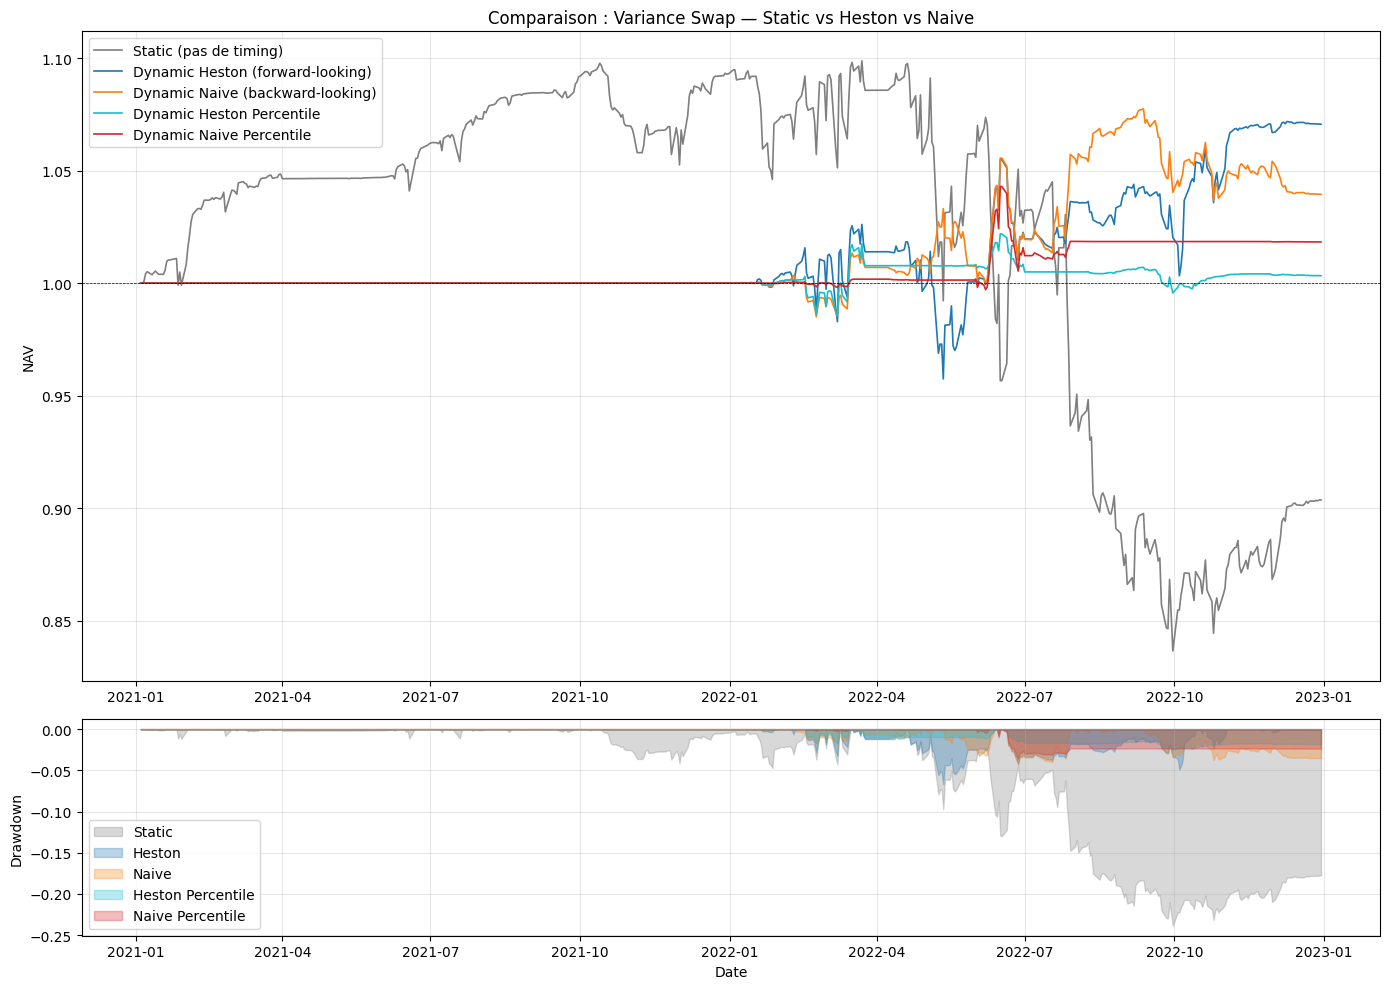

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

# NAV
ax1 = axes[0]
for name, bt, color in [
    ("Static (pas de timing)", bt_static, "tab:gray"),
    ("Dynamic Heston (forward-looking)", bt_heston, "tab:blue"),
    ("Dynamic Naive (backward-looking)", bt_naive, "tab:orange"),
    ("Dynamic Heston Percentile", bt_percentile_heston, "tab:cyan"),
    ("Dynamic Naive Percentile", bt_percentile_naive, "tab:red"),
]:
    nav = bt.nav["NAV"]
    ax1.plot(nav.index, nav.values, label=name, color=color, linewidth=1.2)

ax1.axhline(1.0, color="black", linewidth=0.5, linestyle="--")
ax1.set_ylabel("NAV")
ax1.set_title("Comparaison : Variance Swap — Static vs Heston vs Naive")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3)

# Drawdown
ax2 = axes[1]
for name, bt, color in [
    ("Static", bt_static, "tab:gray"),
    ("Heston", bt_heston, "tab:blue"),
    ("Naive", bt_naive, "tab:orange"),
    ("Heston Percentile", bt_percentile_heston, "tab:cyan"),
    ("Naive Percentile", bt_percentile_naive, "tab:red"),
]:
    nav = bt.nav["NAV"]
    dd = (nav / nav.cummax()) - 1
    ax2.fill_between(dd.index, dd.values, 0, alpha=0.3, color=color, label=name)

ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Date")
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()



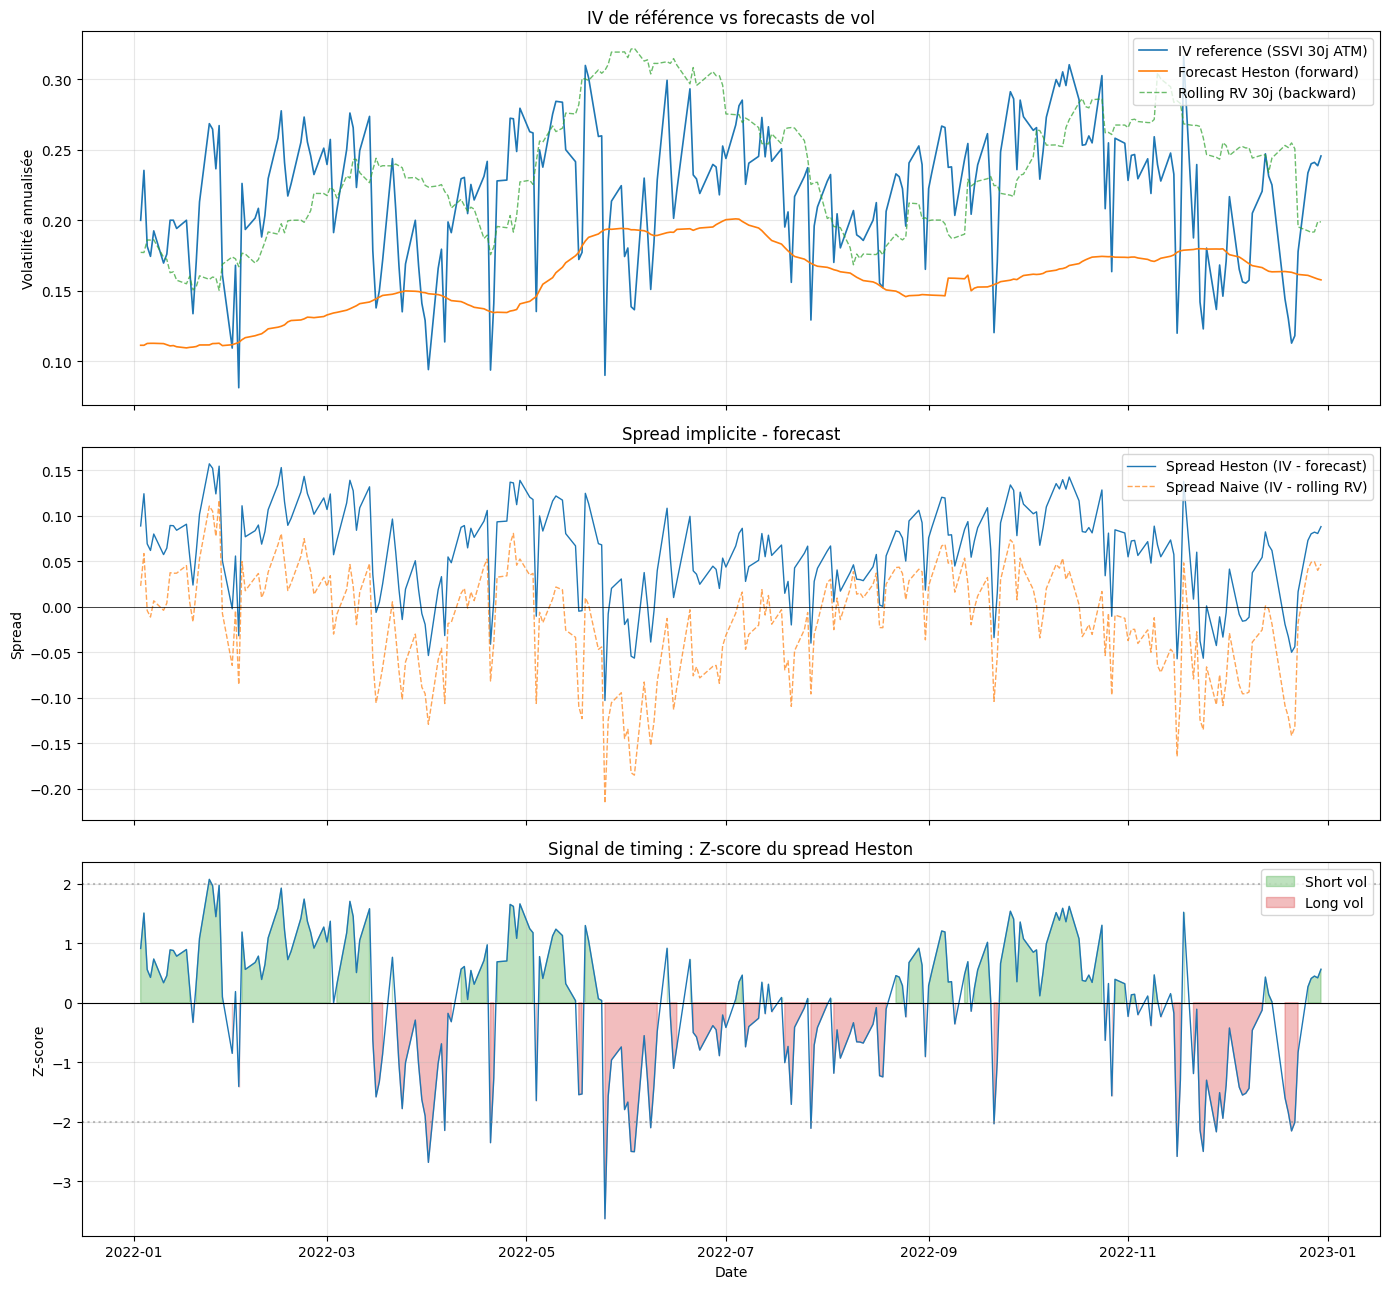

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

df_plot = (
    df_spread
    .merge(
        df_allocation[["date", "ticker", "allocation", "spread_zscore"]],
        on=["date", "ticker"], how="inner",
    )
    .sort_values("date")
)

# IV vs Heston vs Naive realized vol
ax1 = axes[0]
ax1.plot(df_plot["date"], df_plot["iv_reference"], label="IV reference (SSVI 30j ATM)", linewidth=1.2)
ax1.plot(df_plot["date"], df_plot["forecast_volatility"], label="Forecast Heston (forward)", linewidth=1.2)

# Realized vol naive
df_naive_plot = df_spread_naive[["date", "ticker", "rolling_realized_vol"]].copy()
df_plot_merged = df_plot.merge(df_naive_plot, on=["date", "ticker"], how="left")
ax1.plot(df_plot_merged["date"], df_plot_merged["rolling_realized_vol"],
         label="Rolling RV 30j (backward)", linewidth=1.0, linestyle="--", alpha=0.7)

ax1.set_ylabel("Volatilité annualisée")
ax1.legend(loc="upper right")
ax1.set_title("IV de référence vs forecasts de vol")
ax1.grid(alpha=0.3)

# Spread Heston vs Spread naive
ax2 = axes[1]
ax2.plot(df_plot["date"], df_plot["spread"], label="Spread Heston (IV - forecast)", linewidth=1.0)

df_naive_spread_plot = df_spread_naive[["date", "ticker", "spread"]].rename(columns={"spread": "spread_naive"})
df_plot_merged2 = df_plot.merge(df_naive_spread_plot, on=["date", "ticker"], how="left")
ax2.plot(df_plot_merged2["date"], df_plot_merged2["spread_naive"],
         label="Spread Naive (IV - rolling RV)", linewidth=1.0, linestyle="--", alpha=0.7)

ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_ylabel("Spread")
ax2.legend(loc="upper right")
ax2.set_title("Spread implicite - forecast")
ax2.grid(alpha=0.3)

# Z-score Heston
ax3 = axes[2]
zscore = df_plot["spread_zscore"]
ax3.plot(df_plot["date"], zscore, color="tab:blue", linewidth=1.0)
ax3.fill_between(df_plot["date"], zscore, 0, where=(zscore > 0),
                 alpha=0.3, color="tab:green", label="Short vol")
ax3.fill_between(df_plot["date"], zscore, 0, where=(zscore < 0),
                 alpha=0.3, color="tab:red", label="Long vol")
ax3.axhline(0, color="black", linewidth=0.8)
ax3.axhline(2, color="gray", linestyle=":", alpha=0.5)
ax3.axhline(-2, color="gray", linestyle=":", alpha=0.5)
ax3.set_ylabel("Z-score")
ax3.set_xlabel("Date")
ax3.legend(loc="upper right")
ax3.set_title("Signal de timing : Z-score du spread Heston")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 1400x1000 with 2 Axes>